In [10]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

crime_df = pd.read_csv("USArrests.csv")
crime_df.head()

,State,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


# Clustering

<function matplotlib.pyplot.show(close=None, block=None)>

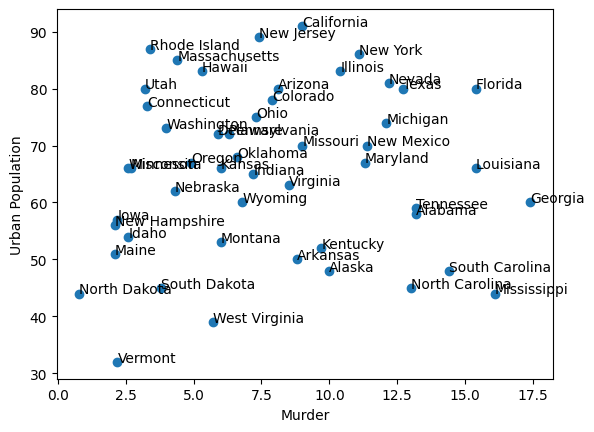

In [13]:
from sklearn.cluster import KMeans

X = crime_df.drop('State',axis=1)
y = crime_df['State']

plt.scatter(X['Murder'], X['UrbanPop'])

# enumerating allows us to keep track
# of the indexes associated with each iteration
for i, txt in enumerate(y):
    plt.annotate(txt, (X['Murder'][i],X['UrbanPop'][i]))

plt.xlabel('Murder')
plt.ylabel("Urban Population")
plt.show

In [ ]:
inertias = []
distortions = []

for k in range(1,10):
    model = KMeans(n_clusters=k).fit(X)

    # Distortion is the average of the squared
    # distance from the cluster center
    # to the data points (in Euclidean space)
    # Euclidean space = standard 2+ dimensional space
    distance = cdist(X, model.cluster_centers_,
                        'euclidean')
    distortion = sum(np.min(distance, axis=1))/X.shape[0]
    distortions.append(distortion)
    
    # inertia is calculation by measuring the distance between each data point and the centroid and summing the square
    # across the cluster. A good model is one with low inertia or distortion AND a low number of clusters
    inertia = model.inertia_
    inertias.append(inertia)


In [ ]:
plt.plot(range(1,10), distortion)

In [ ]:
plt.plot(range(1,20), inertias)


# Hierarchical

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(X, 'ward')
plt.figure(figsize = )

In [ ]:
from sklearn.cluster import AgglomerativeClustering
# divides the population into several clusters
# so that the data points that are in the same cluster
# as other data points are most similar to each other.
# Those in different clusters are more dissimilar.

cluster = AgglomerativeClustering(n_clusters=3, linkage = 'ward')
cluster.fit_predict(X)


In [ ]:
plt.figure(figsize=(10,10))
plt.scatter(X['Murder'],X['UrbanPop'], c=cluster.labels_)
for i, txt in enumerate(y):
    plt.annotate(txt, (X['Murder'][i], X['UrbanPop'][i]))
    

# Dimensionality Reduction
what column can we remove to reduce the chance of overfitting

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
diabetes_df = pd.read_csv()

In [ ]:
X = diabetes_df.drop('Outcome', axis = 1)
y= diabetes_df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size = 0.3,
                                                    random_state=43,
                                                    )

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions()

In [ ]:
from sklearn.decomposition import TruncatedSVD
# singular value decomposition = factorization
# technique for real or complex numbers in a matrix
# in short, it is untangling patterns in the numbers
# using matrix decomposition (linear algebra concept)
# truncatedSVD is typically used for sparse datasets (unlike frkkkkkkkkkkk)
svd = TruncatedSVD(n_componets=6)
X_train_svd = svd.fit_transform(X_train)
X_test_svd = svd.fit.transform(X_test)

model = LogisticRegression (random_state=50).fit(X_train_svd)
model.score(X_test_svd, y_test)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
